### 1. Importing Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
df = pd.read_csv('/content/train.csv')

print("=" * 80)
print("INITIAL DATA OVERVIEW")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
print(df.head())

INITIAL DATA OVERVIEW
Dataset shape: (45593, 20)

Column names:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']

Data types:
ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_conditi

### 2. Data Preprocessing

In [5]:
df['ID'] = df['ID'].str.strip()

In [6]:
df['Delivery_person_ID'] = df['Delivery_person_ID'].str.strip()

In [7]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.extract(r'(\d+)').astype(float)

In [8]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)

In [9]:
df['Road_traffic_density'] = df['Road_traffic_density'].str.strip()

In [10]:
print("\nMissing values before handling:")
print(df.isnull().sum())


Missing values before handling:
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [11]:
# Replace 'NaN ' strings with actual NaN
df = df.replace('NaN ', np.nan)
df = df.replace('NaN', np.nan)

In [12]:
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition',
                'multiple_deliveries']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nMissing values after conversion:")
print(df.isnull().sum())


Missing values after conversion:
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64


In [13]:
# Handle date columns
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day
df['DayOfWeek'] = df['Order_Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [14]:
# Handle time columns
def extract_time(time_str):
    try:
        if pd.isna(time_str) or time_str == 'NaN ':
            return np.nan
        return pd.to_datetime(time_str, format='%H:%M:%S').time()
    except:
        return np.nan

In [15]:
df['Time_Orderd'] = df['Time_Orderd'].apply(extract_time)
df['Time_Order_picked'] = df['Time_Order_picked'].apply(extract_time)

In [16]:
# Calculate time difference if both times are available

def time_diff(order_time, picked_time):
    if pd.isna(order_time) or pd.isna(picked_time):
        return np.nan
    order = datetime.combine(datetime.today(), order_time)
    picked = datetime.combine(datetime.today(), picked_time)
    diff = (picked - order).total_seconds() / 60
    if diff < 0:  # Handle cases where pickup is on next day
        diff += 24*60
    return diff

df['Time_to_assign'] = df.apply(lambda x: time_diff(x['Time_Orderd'], x['Time_Order_picked']), axis=1)

In [17]:
location_cols = ['Restaurant_latitude', 'Restaurant_longitude',
                 'Delivery_location_latitude', 'Delivery_location_longitude']

for col in location_cols:
    # Mark zeros as invalid
    df.loc[df[col] == 0, col] = np.nan

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan

    R = 6371  # Earth's radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [19]:
df['Distance_km'] = df.apply(
    lambda x: haversine(
        x['Restaurant_latitude'], x['Restaurant_longitude'],
        x['Delivery_location_latitude'], x['Delivery_location_longitude']
    ), axis=1
)

### 3. EDA

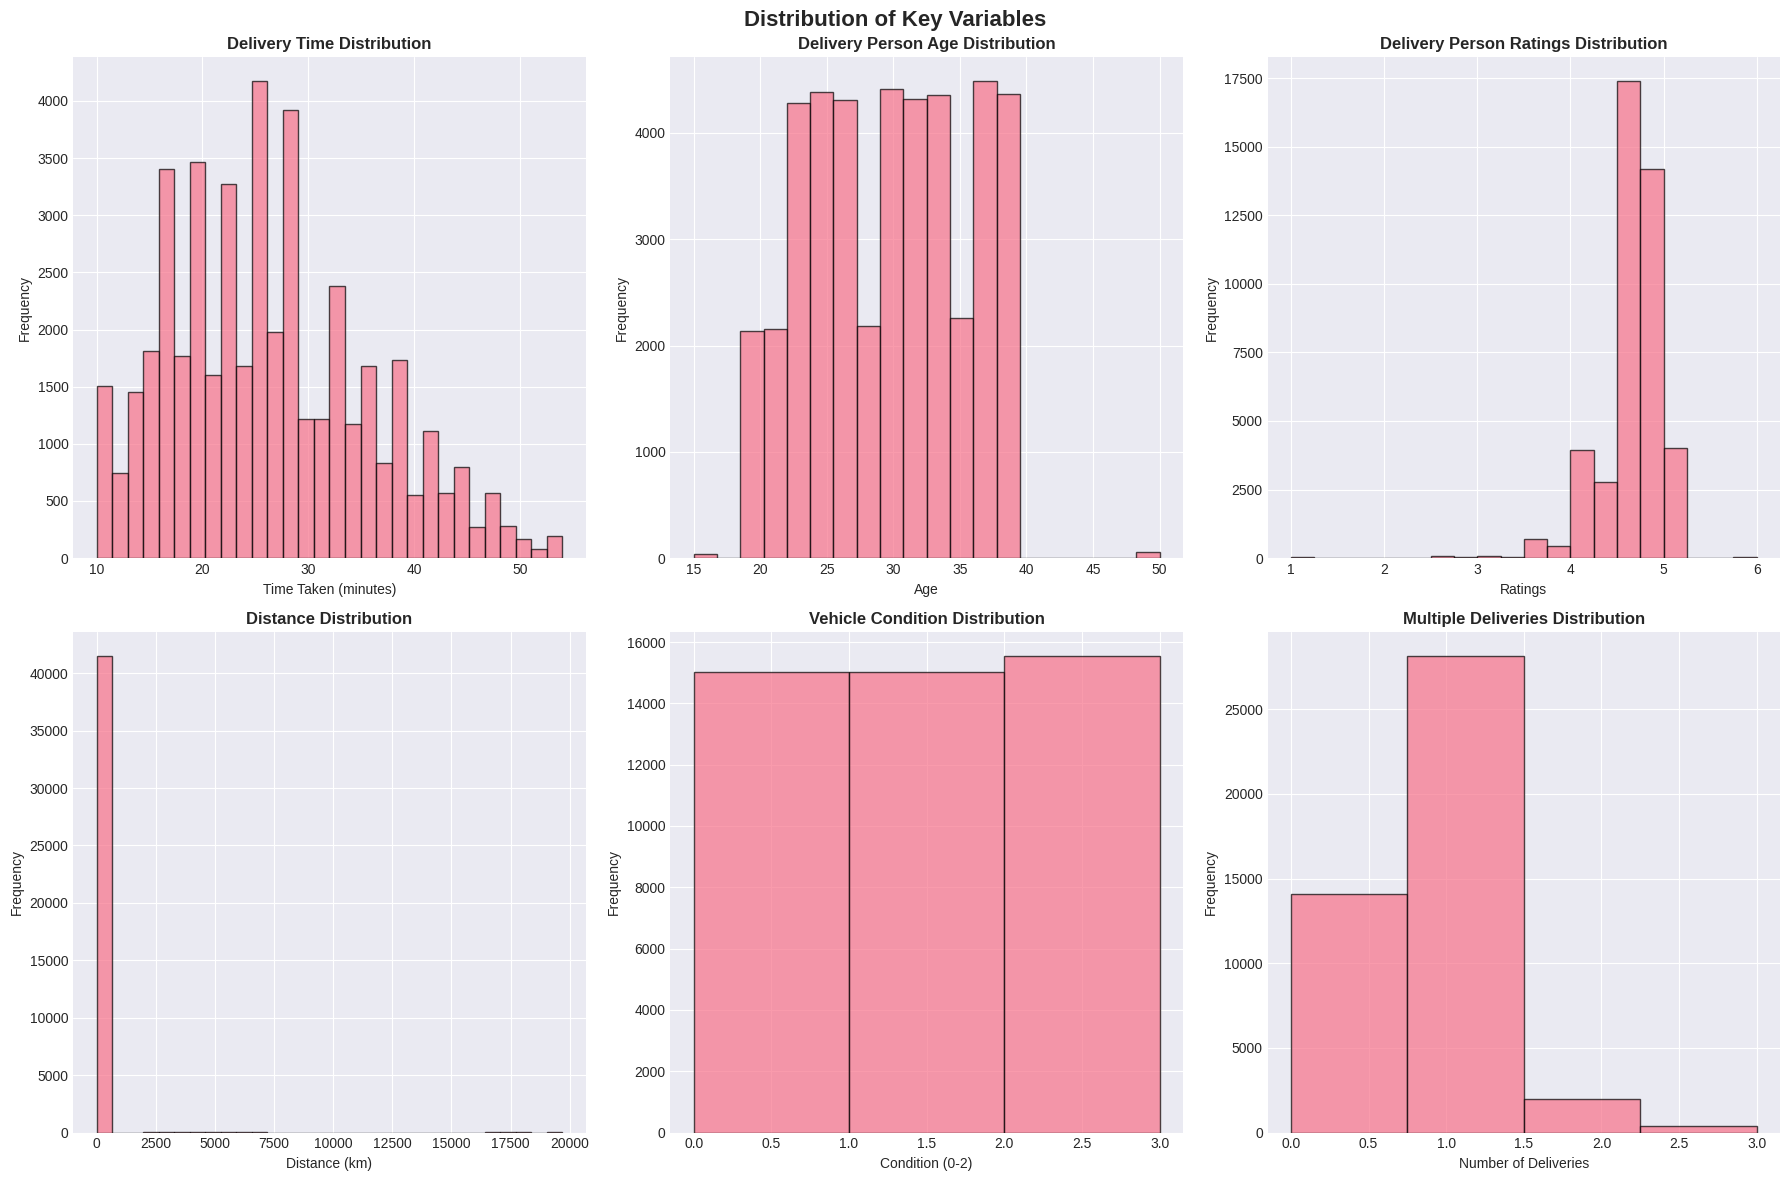

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

# Delivery Time Distribution
axes[0, 0].hist(df['Time_taken(min)'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Delivery Time Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Time Taken (minutes)')
axes[0, 0].set_ylabel('Frequency')

# Delivery Person Age
axes[0, 1].hist(df['Delivery_person_Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Delivery Person Age Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# Delivery Person Ratings
axes[0, 2].hist(df['Delivery_person_Ratings'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Delivery Person Ratings Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Ratings')
axes[0, 2].set_ylabel('Frequency')

# Distance Distribution
axes[1, 0].hist(df['Distance_km'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distance Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('Frequency')

# Vehicle Condition
axes[1, 1].hist(df['Vehicle_condition'].dropna(), bins=3, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Vehicle Condition Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Condition (0-2)')
axes[1, 1].set_ylabel('Frequency')

# Multiple Deliveries
axes[1, 2].hist(df['multiple_deliveries'].dropna(), bins=4, edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Multiple Deliveries Distribution', fontweight='bold')
axes[1, 2].set_xlabel('Number of Deliveries')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

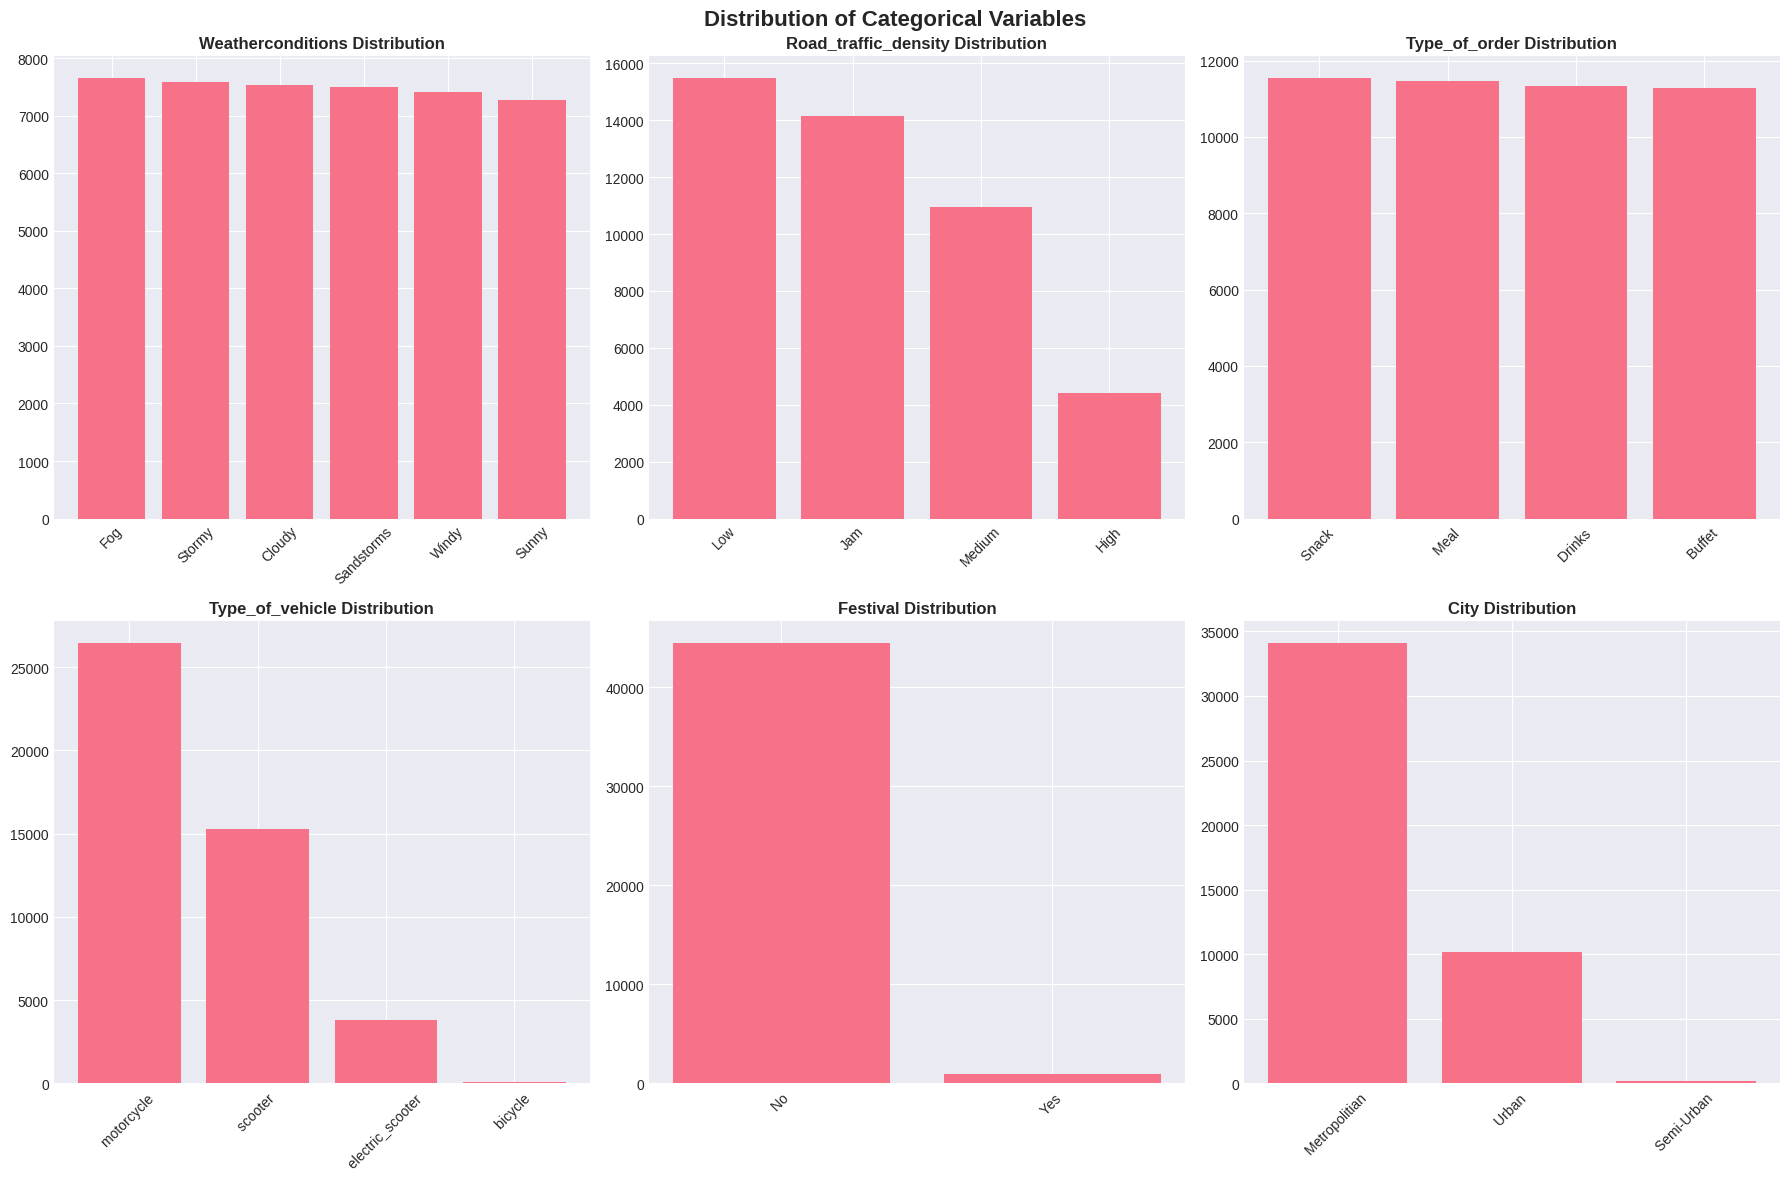

In [21]:
# 2. Categorical Variables Analysis
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
                    'Type_of_vehicle', 'Festival', 'City']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold')

for idx, col in enumerate(categorical_cols):
    row, col_idx = idx // 3, idx % 3
    value_counts = df[col].value_counts()
    axes[row, col_idx].bar(value_counts.index, value_counts.values)
    axes[row, col_idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[row, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

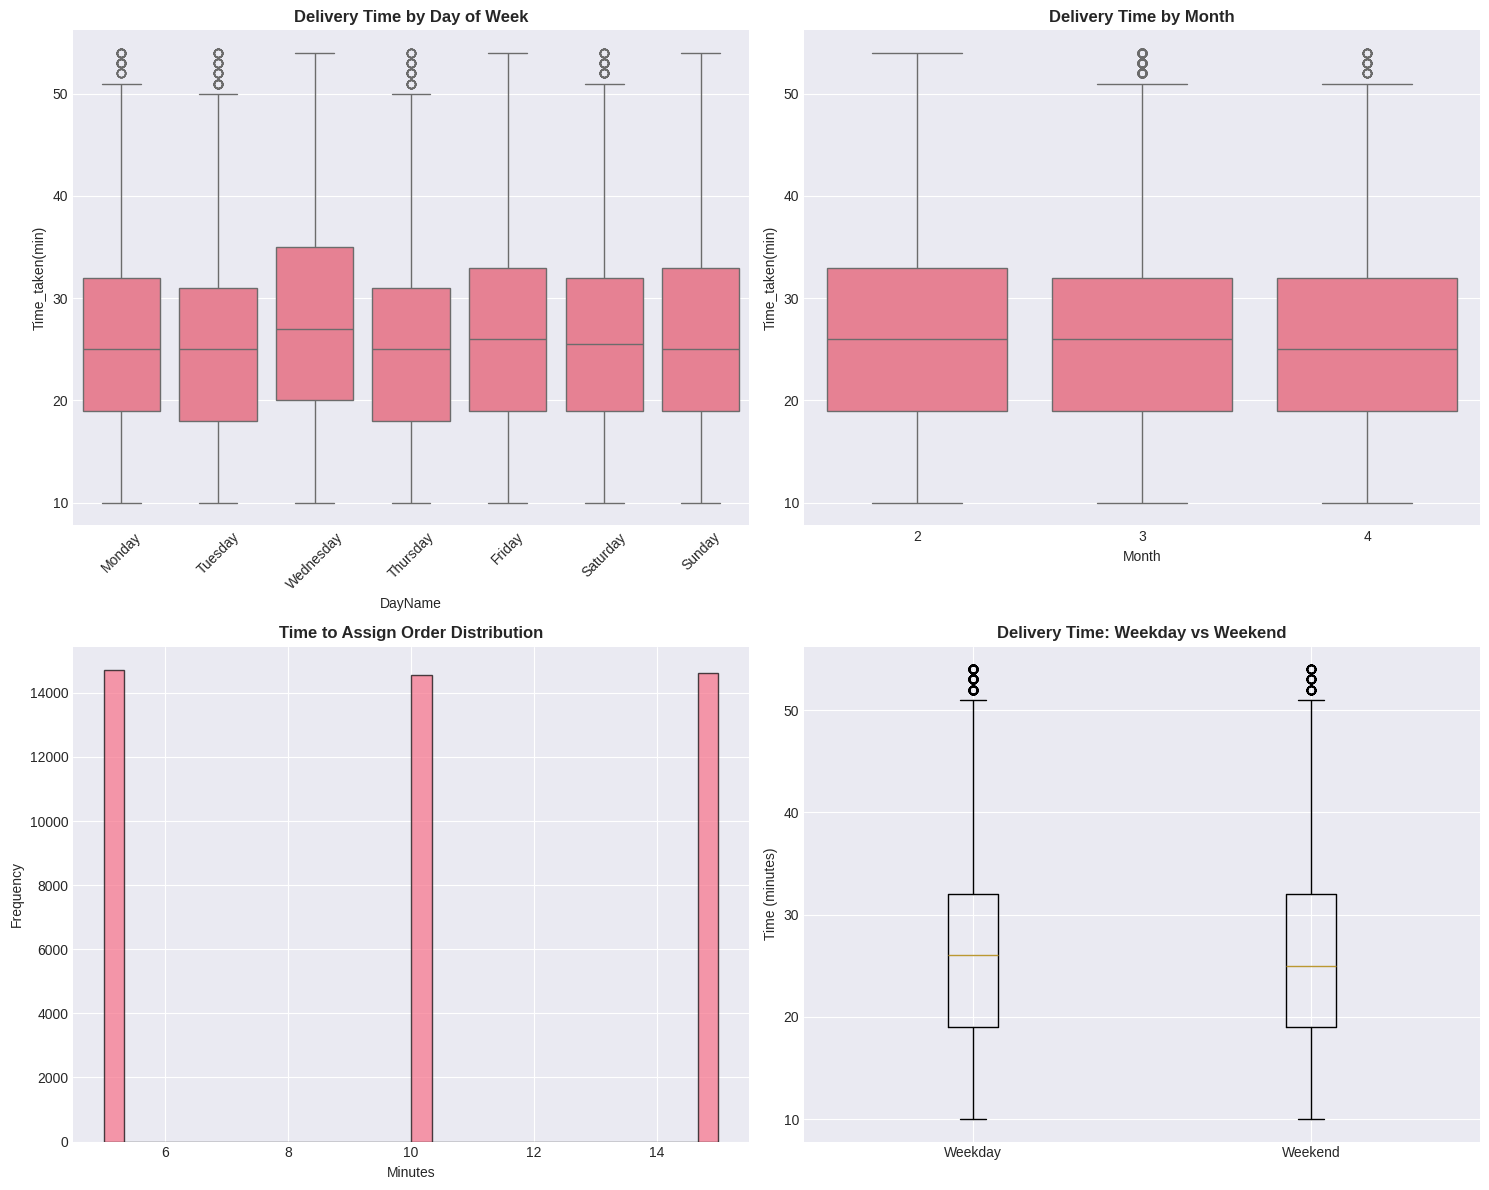

In [22]:
# 3. Time-based Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Delivery time by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayName'] = df['DayOfWeek'].map({0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday',
                                      4:'Friday', 5:'Saturday', 6:'Sunday'})

sns.boxplot(data=df, x='DayName', y='Time_taken(min)', order=day_order, ax=axes[0, 0])
axes[0, 0].set_title('Delivery Time by Day of Week', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Delivery time by month
sns.boxplot(data=df, x='Month', y='Time_taken(min)', ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time by Month', fontweight='bold')

# Time to assign distribution
axes[1, 0].hist(df['Time_to_assign'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Time to Assign Order Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Minutes')
axes[1, 0].set_ylabel('Frequency')

# Delivery time by weekend
weekend_data = [df[df['IsWeekend']==0]['Time_taken(min)'].dropna(),
                df[df['IsWeekend']==1]['Time_taken(min)'].dropna()]
axes[1, 1].boxplot(weekend_data, labels=['Weekday', 'Weekend'])
axes[1, 1].set_title('Delivery Time: Weekday vs Weekend', fontweight='bold')
axes[1, 1].set_ylabel('Time (minutes)')

plt.tight_layout()
plt.show()

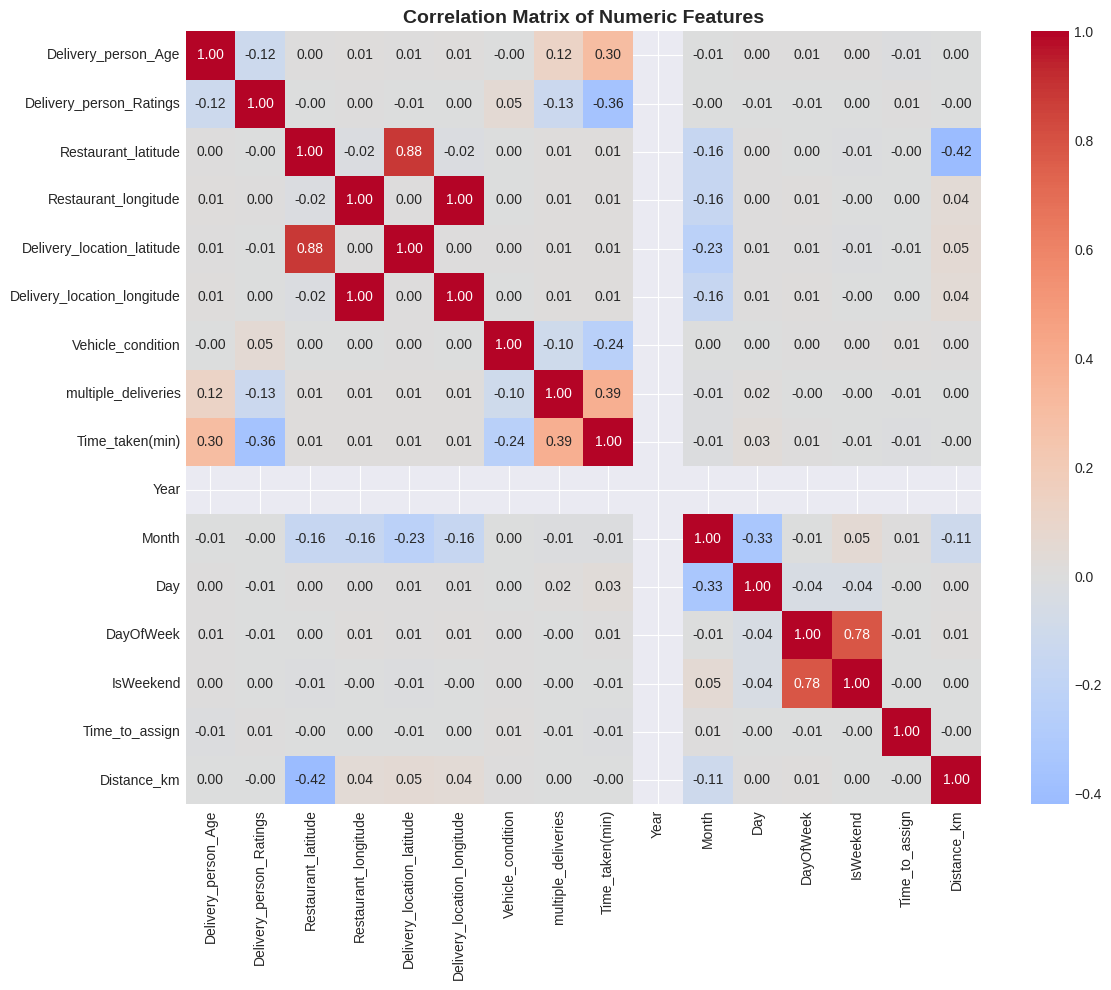

In [23]:
# 4. Correlation Analysis
numeric_df = df.select_dtypes(include=[np.number]).dropna()
plt.figure(figsize=(12, 10))
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

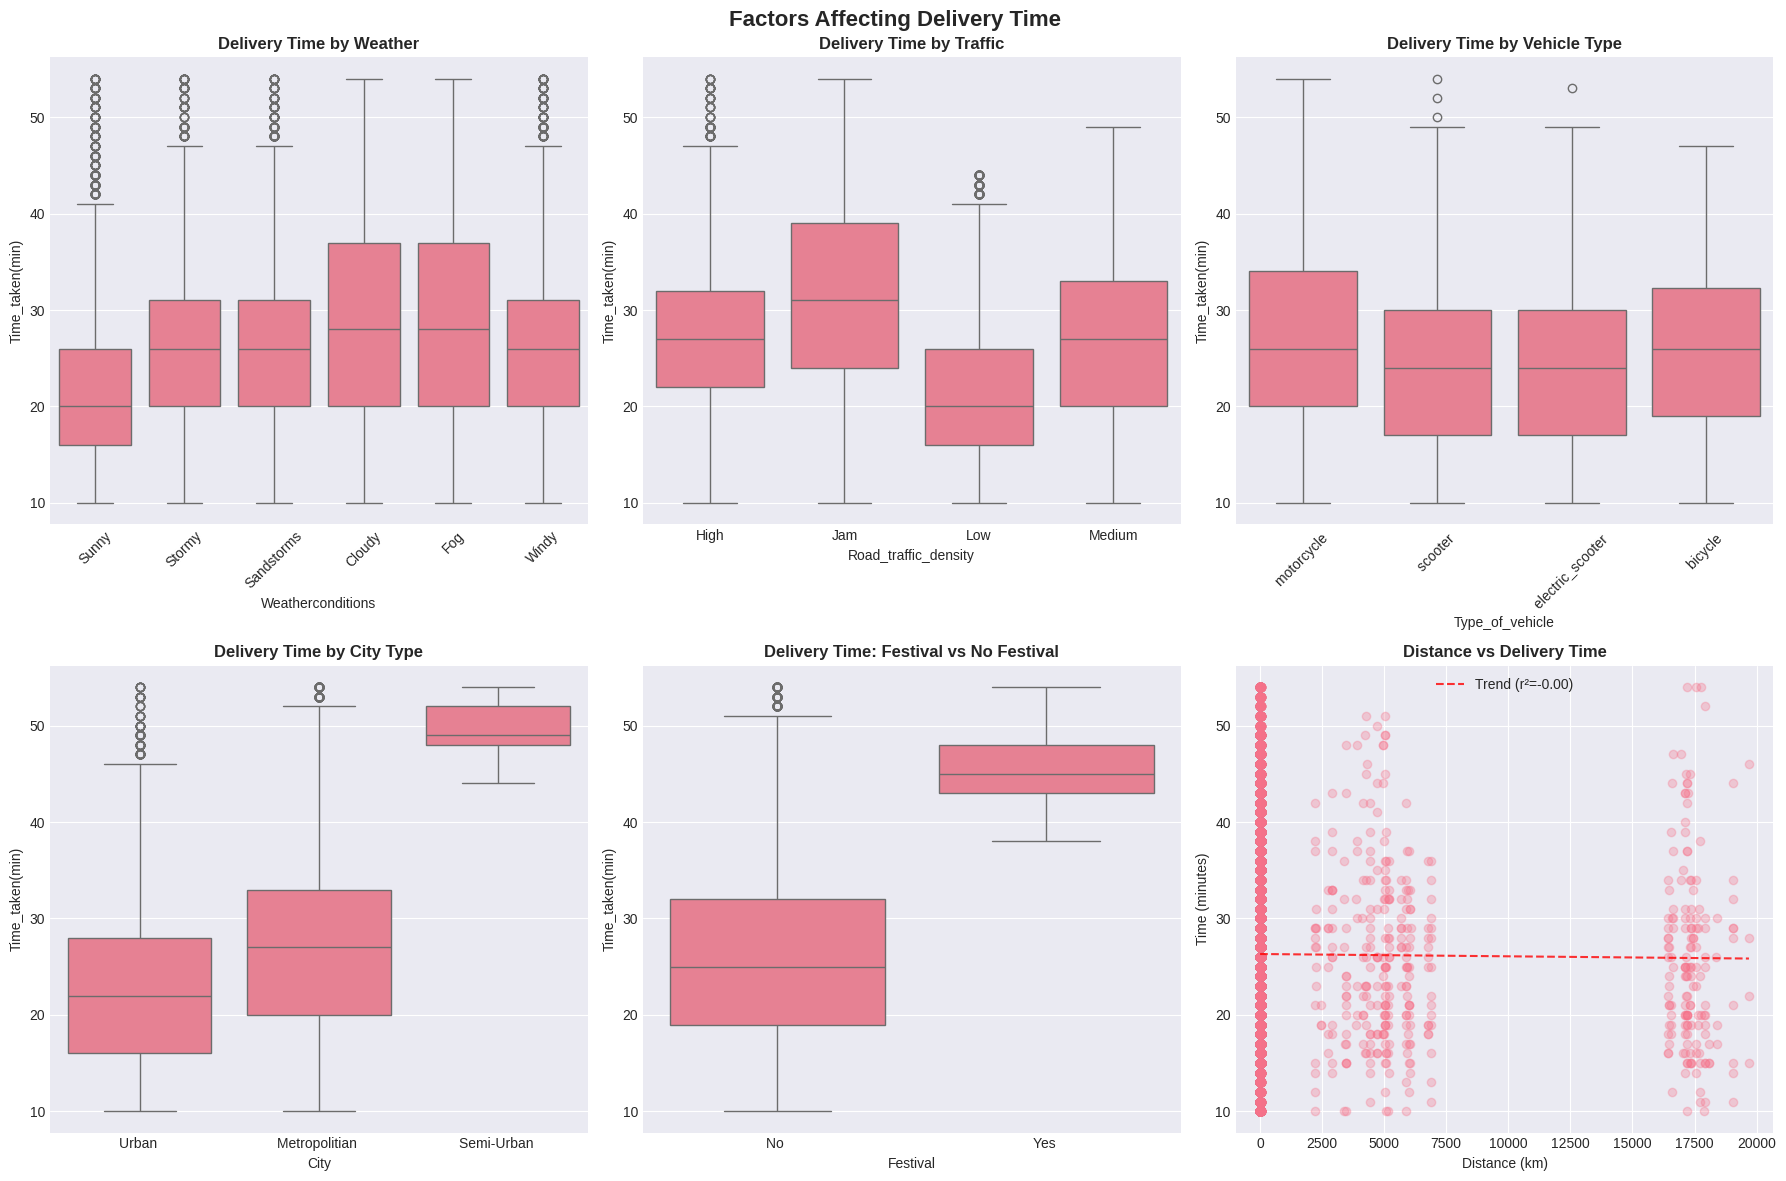

In [24]:
# 5. Relationship with Target Variable
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Factors Affecting Delivery Time', fontsize=16, fontweight='bold')

# Weather conditions
sns.boxplot(data=df, x='Weatherconditions', y='Time_taken(min)', ax=axes[0, 0])
axes[0, 0].set_title('Delivery Time by Weather', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Traffic density
sns.boxplot(data=df, x='Road_traffic_density', y='Time_taken(min)', ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time by Traffic', fontweight='bold')

# Type of vehicle
sns.boxplot(data=df, x='Type_of_vehicle', y='Time_taken(min)', ax=axes[0, 2])
axes[0, 2].set_title('Delivery Time by Vehicle Type', fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45)

# City type
sns.boxplot(data=df, x='City', y='Time_taken(min)', ax=axes[1, 0])
axes[1, 0].set_title('Delivery Time by City Type', fontweight='bold')

# Festival
sns.boxplot(data=df, x='Festival', y='Time_taken(min)', ax=axes[1, 1])
axes[1, 1].set_title('Delivery Time: Festival vs No Festival', fontweight='bold')

# Scatter: Distance vs Time
axes[1, 2].scatter(df['Distance_km'], df['Time_taken(min)'], alpha=0.3)
axes[1, 2].set_title('Distance vs Delivery Time', fontweight='bold')
axes[1, 2].set_xlabel('Distance (km)')
axes[1, 2].set_ylabel('Time (minutes)')

# Add trend line
temp_df_for_polyfit = df[['Distance_km', 'Time_taken(min)']].dropna()
z = np.polyfit(temp_df_for_polyfit['Distance_km'], temp_df_for_polyfit['Time_taken(min)'], 1)
p = np.poly1d(z)
axes[1, 2].plot(temp_df_for_polyfit['Distance_km'].sort_values(),
                p(temp_df_for_polyfit['Distance_km'].sort_values()),
                "r--", alpha=0.8, label=f'Trend (r²={z[0]:.2f})')
axes[1, 2].legend()

plt.tight_layout()
plt.show()